# ML-Assisted Detection of  IoT Botnet DDoS Attacks: An Ensemble Learning Approach


 The rapid growth of IoT devices has expanded network attack surfaces,
 making them frequent targets for botnet-driven DDoS attacks. Traditional
signature-based detection methods struggle to keep pace with the scale
and sophistication of modern IoT threats.

 This notebook presents a comparative analysis of five ensemble learning
 models for DDoS attack detection in SDN-IoT environments:

   - Random Forest
   - Extra Trees
   - AdaBoost
   - LightGBM
   - XGBoost

 The best-performing model is selected and deployed in a real SDN-IoT
 emulation environment using Mininet and the POX controller, bridging
 the gap between offline evaluation and real-world network security.

 ### Objectives:
   1. Benchmark all five ensemble models on IoT botnet DDoS traffic data
   2. Identify the top-performing model based on key metrics
   3. Deploy the selected model within a live SDN-IoT to either implement DDoS detection or generate Custom Dataset.
   
author: Kananelo Chabeli <br>
Date: 27-03-2026



In [1]:
#Data Processing and Numerical Analyssis
import numpy as np
import pandas as pd

#Data Visualization
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

#Data Preprocessing & Feature Engineering 
from sklearn.preprocessing import LabelEncoder,MinMaxScaler,StandardScaler
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.utils import resample

#Ensemble Learning Models 
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import ExtraTreesClassifier
from sklearn.ensemble import AdaBoostClassifier
from sklearn.ensemble import VotingClassifier
from catboost import CatBoostClassifier
from sklearn.utils.class_weight import compute_class_weight
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from sklearn.tree import DecisionTreeClassifier
#Model Evaluation Metrics
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
)

#Utility & System 
import os
import time
import warnings
import psutil
import threading
import joblib
import json
warnings.filterwarnings("ignore")


#Display Settings
pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda x: f"{x:.4f}")
%matplotlib inline

In [25]:
PARENT_DIRECTORY = '/home/chabeli/SDN_IoT/sdn-iot'


## Data Loading and Preprocessing


The models are trained and evaluated on CICIoT-DIAD2004 Dataset, which contains about 50 million records of 88 features and 13 attach types. The csv  are not made availabke on Github due to thier size, but may be downloaded at [CICIoT-DIAD2024](https://www.unb.ca/cic/datasets/iot-diad-2024.html).

### Step 1: Loading & Concatenating Datasets

#### Step 1.1: Check Datasets filenames

I saved the datasets are in the ../../Datasets/IoTDatasets directory ( use the directory where you saved them after downloading them). They are make sure you correct the labeling column of each csv file as the owners of the dataset did not label them. I used "BENIGN" for begin.csv, "ACK_FLOOD" for ack_flood.csv and so on as file, just use any label appropriate to you.

In [26]:
DATASET_PATH = "/home/chabeli/SDN_IoT/Dataset/IoTDataSet" 

#Check for datasets files, and  print thier filenames. If no Filename is printed, 
#there's something wrong is how you passed your dataset folder.
csv_files = [f for f in os.listdir(DATASET_PATH) if f.endswith(".csv")]
print(f"📂 Found {len(csv_files)} CSV files:")
for f in csv_files:
    print(f"   └── {f}")

📂 Found 5 CSV files:
   └── DDoS-ICMP_Flood.pcap_Flow.csv
   └── DDoS-HTTP_Flood-.pcap_Flow.csv
   └── DDoS-ACK_Fragmentation.pcap_Flow.csv
   └── DDoS-ICMP_Fragmentation.pcap_Flow.csv
   └── BenignTraffic.pcap_Flow.csv


#### Step 1.2: Loading and concatenating all datasets.

we randomly sample equal samples from each attack dataset, to make the number of records in BeginTraffic dataset.

In [27]:
BENIGN_FILE  = "BenignTraffic.pcap_Flow.csv"
ATTACK_FILES = [
    "DDoS-ICMP_Flood.pcap_Flow.csv",
    "DDoS-HTTP_Flood-.pcap_Flow.csv",
    "DDoS-ACK_Fragmentation.pcap_Flow.csv",
    "DDoS-ICMP_Fragmentation.pcap_Flow.csv",
]

# #load BENIGN Traffc dataset to get the sample size.
benign_df = pd.read_csv(os.path.join(DATASET_PATH, BENIGN_FILE))
SAMPLE_SIZE = len(benign_df)

#We want to print, so that we can check if we doing correct things!
print(f"✅ Loaded Benign Traffic  →  Shape: {benign_df.shape}")
print(f"   Classes found         :  {benign_df['Label'].unique()}")
print(f"\n📏 Benchmark sample size (per class) : {SAMPLE_SIZE:,}\n")

# Load & downsample each attack file to match Benign size 
dataframes = [benign_df]

for file in ATTACK_FILES:
    filepath = os.path.join(DATASET_PATH, file)
    df_temp  = pd.read_csv(filepath)
    original_size = len(df_temp)

    # Sample min(available, SAMPLE_SIZE) to handle files smaller than benign
    n_samples = min(original_size, SAMPLE_SIZE)
    df_sampled = df_temp.sample(n=n_samples, random_state=42).reset_index(drop=True)
    
    #printing just makes things pretty
    print(f"✅ Loaded : {file}")
    print(f"   Original size  : {original_size:>10,}  →  Sampled: {n_samples:,}")
    print(f"   Classes found  : {df_sampled['Label'].unique()}\n")

    dataframes.append(df_sampled)

#Step 3: Concatenate & shuffle
df = pd.concat(dataframes, ignore_index=True)
df = df.sample(frac=1, random_state=42).reset_index(drop=True)

#Lets just print so that we can be sure than our things worked out pretty well
print(f"{'='*55}")
print(f"  ✅ Merged Dataset Shape  : {df.shape}")
print(f"  ✅ Total Classes         : {df['Label'].nunique()}")
print(f"\n  📊 Final Class Distribution:")
dist = df['Label'].value_counts()
for label, count in dist.items():
    print(f"    {label:<40} : {count:>8,}")
print(f"{'='*55}")

✅ Loaded Benign Traffic  →  Shape: (183630, 84)
   Classes found         :  ['BENIGN']

📏 Benchmark sample size (per class) : 183,630

✅ Loaded : DDoS-ICMP_Flood.pcap_Flow.csv
   Original size  :     10,415  →  Sampled: 10,415
   Classes found  : ['ICMP_FLOOD']

✅ Loaded : DDoS-HTTP_Flood-.pcap_Flow.csv
   Original size  :    505,720  →  Sampled: 183,630
   Classes found  : ['HTTP_FLOOD']

✅ Loaded : DDoS-ACK_Fragmentation.pcap_Flow.csv
   Original size  :    323,886  →  Sampled: 183,630
   Classes found  : ['ACK_FRAG']

✅ Loaded : DDoS-ICMP_Fragmentation.pcap_Flow.csv
   Original size  :     14,479  →  Sampled: 14,479
   Classes found  : ['ICMP_FREG']

  ✅ Merged Dataset Shape  : (575784, 84)
  ✅ Total Classes         : 5

  📊 Final Class Distribution:
    HTTP_FLOOD                               :  183,630
    BENIGN                                   :  183,630
    ACK_FRAG                                 :  183,630
    ICMP_FREG                                :   14,479
    ICMP_FLO

In [28]:
sizes = [ds.shape[0] for ds in dataframes]

sizes
    

[183630, 10415, 183630, 183630, 14479]

In [29]:
class_nums= [('BENIGN', 183630), ('ICMP_FLOOD',10415), ('HTTP_FLOOD',183630), 
             ('ACK_FRAGMENTATION', 183630), ('ICMP_FRAGMENTATION', 14479),
            ('TOTAL', sum(sizes))]


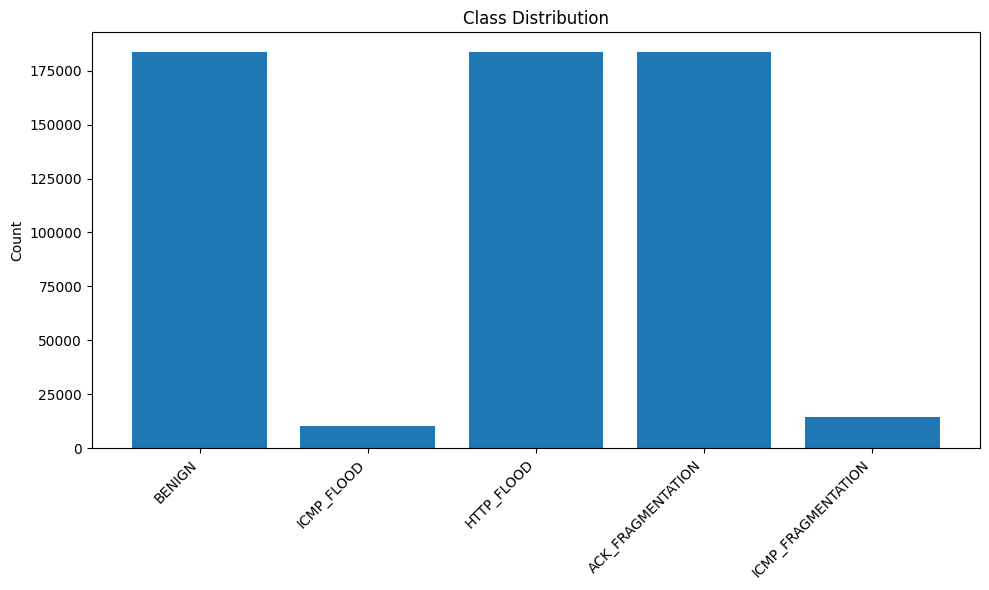

In [30]:
class_nums = [('BENIGN', 183630), ('ICMP_FLOOD', 10415), ('HTTP_FLOOD', 183630), 
              ('ACK_FRAGMENTATION', 183630), ('ICMP_FRAGMENTATION', 14479)]

labels, values = zip(*class_nums)

plt.figure(figsize=(10, 6))
plt.bar(labels, values)
plt.xticks(rotation=45, ha='right')
plt.title('Class Distribution')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

In [31]:
sum(sizes)

575784

### Step 2: Data Exploration and Sanity Checks

Before any cleaning, we perform a structural audit of the merged dataset.
This includes checking shapes, dtypes, missing values, duplicates, and
the presence of infinite values.


In [32]:

print("=" * 55)
print("  DATASET OVERVIEW")
print("=" * 55)
print(f"  Rows         : {df.shape[0]:,}")
print(f"  Columns      : {df.shape[1]}")
print(f"  Memory Usage : {df.memory_usage(deep=True).sum() / 1e6:.2f} MB")

#  Data types 
print("\n📋 Column Data Types:")
print(df.dtypes.value_counts())

# Missing values 
missing = df.isnull().sum()
missing_pct = (missing / len(df)) * 100
missing_report = pd.DataFrame({
    "Missing Count": missing,
    "Missing (%)": missing_pct
}).query("`Missing Count` > 0").sort_values("Missing (%)", ascending=False)

print(f"\n🔍 Columns with Missing Values: {len(missing_report)}")
print(missing_report if not missing_report.empty else "   None found ✅")

# Infinite values 
numeric_cols = df.select_dtypes(include=[np.number]).columns
inf_counts = np.isinf(df[numeric_cols]).sum()
inf_report = inf_counts[inf_counts > 0]

print(f"\n🔍 Columns with Infinite Values: {len(inf_report)}")
print(inf_report if not inf_report.empty else "   None found ✅")

# Duplicate rows 
duplicate_count = df.duplicated().sum()
print(f"\n🔍 Duplicate Rows: {duplicate_count:,}")

# Summary statistics
print("\n📊 Summary Statistics (numeric features):")
df.describe().T

  DATASET OVERVIEW
  Rows         : 575,784
  Columns      : 84
  Memory Usage : 585.43 MB

📋 Column Data Types:
int64      55
float64    24
object      5
Name: count, dtype: int64

🔍 Columns with Missing Values: 1
              Missing Count  Missing (%)
Flow Bytes/s            449       0.0780

🔍 Columns with Infinite Values: 2
Flow Bytes/s       55
Flow Packets/s    504
dtype: int64

🔍 Duplicate Rows: 854

📊 Summary Statistics (numeric features):


,count,mean,std,min,25%,50%,75%,max
Src Port,575784.0000,23927.3078,23411.5603,0.0000,80.0000,21131.5000,47034.0000,65534.0000
Dst Port,575784.0000,18863.9177,20421.6604,0.0000,443.0000,8080.0000,37437.0000,65535.0000
Protocol,575784.0000,8.4503,4.6493,0.0000,6.0000,6.0000,6.0000,17.0000
Flow Duration,575784.0000,17075884.1984,32403338.3912,0.0000,52742.0000,382562.0000,14471759.5000,120000000.0000
Total Fwd Packet,575784.0000,56.6383,4408.6282,1.0000,1.0000,2.0000,4.0000,654631.0000
...,...,...,...,...,...,...,...,...
Active Min,575784.0000,502538.4313,2172101.3552,0.0000,0.0000,0.0000,0.0000,113233293.0000
Idle Mean,575784.0000,10108852.8245,22700688.9864,0.0000,0.0000,0.0000,6875445.0000,119998778.0000
Idle Std,575784.0000,703567.3540,4074541.9000,0.0000,0.0000,0.0000,0.0000,73318132.9601
Idle Max,575784.0000,10732748.8175,23430221.8050,0.0000,0.0000,0.0000,7199418.2500,119998778.0000


### Step 3: Clean Infinities, Missing Values & Duplicates


Flow-based features like Flow Bytes/s can produce inf values when flow
duration is zero. We replace inf with NaN, then impute using column medians.
Duplicate rows are dropped to prevent bias during training.

In [33]:

print("🧹 Starting Data Cleaning...\n")



# Replace inf/-inf with NaN
inf_before = np.isinf(df[numeric_cols]).sum().sum()
df.replace([np.inf, -np.inf], np.nan, inplace=True)
print(f"  ♻️  Replaced {inf_before} infinite values with NaN")

#Drop flow ID, Src IP/Port, Dst IP/Port, Protocol columns
df.drop(columns = ["Flow ID","Src IP", "Src Port", "Dst IP", "Dst Port", "Protocol","Timestamp"], 
        inplace = True)

#Drop columns with >50% missing values
threshold = 0.50
cols_before = df.shape[1]
missing_pct_updated = df.isnull().mean()
cols_to_drop = missing_pct_updated[missing_pct_updated > threshold].index.tolist()
df.drop(columns=cols_to_drop, inplace=True)
print(f"  🗑️  Dropped {len(cols_to_drop)} columns exceeding {int(threshold*100)}% missing: {cols_to_drop}")

# Impute remaining NaNs with column median 
numeric_cols = df.select_dtypes(include=[np.number]).columns
nan_before = df[numeric_cols].isnull().sum().sum()
df[numeric_cols] = df[numeric_cols].fillna(df[numeric_cols].median())
print(f"  🔧 Imputed {nan_before} NaN values using column medians")

# Drop duplicate rows 
dupes_before = df.duplicated().sum()
df.drop_duplicates(inplace=True)
df.reset_index(drop=True, inplace=True)
print(f"  🗑️  Dropped {dupes_before:,} duplicate rows")

# Verify
print(f"\n{'='*55}")
print(f"  ✅ Cleaned Dataset Shape : {df.shape}")
print(f"  ✅ Remaining NaNs        : {df.isnull().sum().sum()}")
print(f"  ✅ Remaining Infs        : {np.isinf(df[numeric_cols]).sum().sum()}")
print(f"{'='*55}")

🧹 Starting Data Cleaning...

  ♻️  Replaced 559 infinite values with NaN
  🗑️  Dropped 0 columns exceeding 50% missing: []
  🔧 Imputed 1008 NaN values using column medians
  🗑️  Dropped 105,320 duplicate rows

  ✅ Cleaned Dataset Shape : (470464, 77)
  ✅ Remaining NaNs        : 0
  ✅ Remaining Infs        : 0


### Step 4: Label Encoding

 The 'label' column contains string class names. We apply Label Encoding
 to convert these into integer class indices suitable for all models.  A mapping dictionary is saved for interpretability and deployment use.

In [34]:
le = LabelEncoder()

df["Label_Encoded"] = le.fit_transform(df["Label"])

# ── Save class mapping ────────────────────────────────────────────────────────
class_mapping = dict(zip(le.classes_, le.transform(le.classes_)))
reverse_mapping = {v: k for k, v in class_mapping.items()}

print("🏷️  Label Encoding Complete")
print(f"\n  Class Mapping:")
for class_name, code in class_mapping.items():
    count = (df["Label"] == class_name).sum()
    print(f"    [{code}]  {class_name:<25} →  {count:>10,} samples")

print(f"\n  Encoded label column: 'Label_Encoded'")
df[["Label", "Label_Encoded"]].value_counts().sort_index()

🏷️  Label Encoding Complete

  Class Mapping:
    [0]  ACK_FRAG                  →     106,674 samples
    [1]  BENIGN                    →     176,775 samples
    [2]  HTTP_FLOOD                →     162,629 samples
    [3]  ICMP_FLOOD                →      10,129 samples
    [4]  ICMP_FREG                 →      14,257 samples

  Encoded label column: 'Label_Encoded'


Label       Label_Encoded
ACK_FRAG    0                106674
BENIGN      1                176775
HTTP_FLOOD  2                162629
ICMP_FLOOD  3                 10129
ICMP_FREG   4                 14257
Name: count, dtype: int64

In [35]:
df.shape

(470464, 78)

### Step 5: Feature Engineering

With 73 features, we eliminate redundant ones in two passes:<br>
         - Pass 1 — Drop constant/near-constant features (zero/near-zero variance)<br>
         - Pass 2 — Drop one from each highly correlated pair (threshold r > 0.95)<br>
This reduces noise, speeds up training, and improves generalisation.

🔻 Pass 1 — Dropped 9 near-zero variance features:
   ['Bwd PSH Flags', 'Fwd URG Flags', 'Bwd URG Flags', 'URG Flag Count', 'CWR Flag Count', 'ECE Flag Count', 'Fwd Bytes/Bulk Avg', 'Fwd Packet/Bulk Avg', 'Fwd Bulk Rate Avg']

🔻 Pass 2 — Dropped 20 highly correlated features (r > 0.95):
   ['Fwd Packet Length Mean', 'Bwd Packet Length Mean', 'Flow IAT Min', 'Fwd IAT Total', 'Fwd IAT Min', 'Fwd Header Length', 'Bwd Header Length', 'Fwd Packets/s', 'Packet Length Variance', 'ACK Flag Count', 'Average Packet Size', 'Fwd Segment Size Avg', 'Bwd Segment Size Avg', 'Bwd Bytes/Bulk Avg', 'Bwd Packet/Bulk Avg', 'Active Max', 'Active Min', 'Idle Mean', 'Idle Max', 'Idle Min']

  ✅ Features before selection : 76
  ✅ Features after selection  : 47


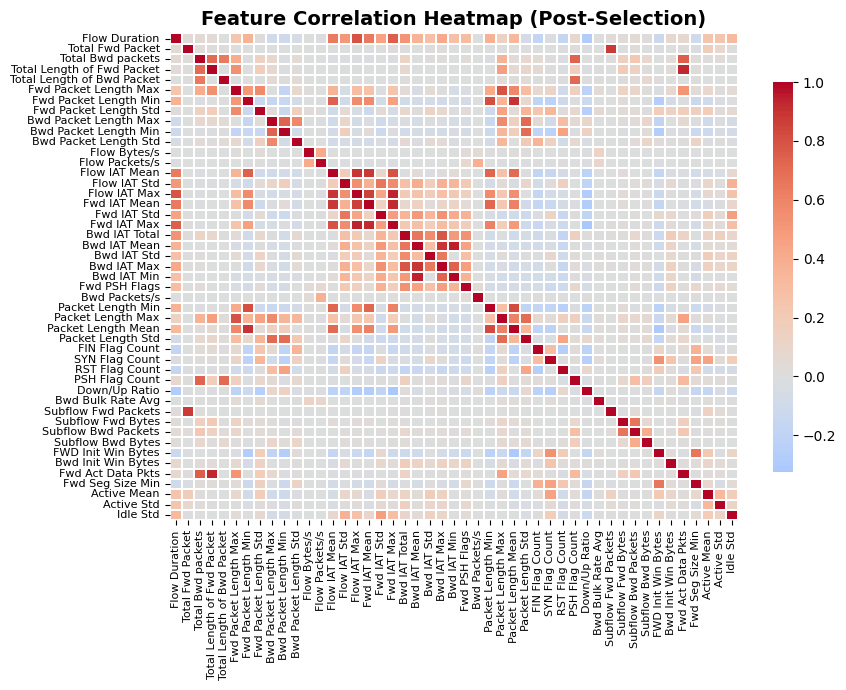

In [37]:

X_raw = df.drop(columns=["Label", "Label_Encoded"])
numeric_cols = X_raw.select_dtypes(include=[np.number]).columns.tolist()

#Pass 1: Remove zero/near-zero variance features
variance = X_raw[numeric_cols].var()
low_var_cols = variance[variance < 0.01].index.tolist()
X_raw.drop(columns=low_var_cols, inplace=True)
print(f"🔻 Pass 1 — Dropped {len(low_var_cols)} near-zero variance features:")
print(f"   {low_var_cols}\n")

#Pass 2: Remove highly correlated features
THRESHOLD = 0.95
corr_matrix = X_raw.corr().abs()
upper_triangle = corr_matrix.where(
    np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)
)
high_corr_cols = [
    col for col in upper_triangle.columns
    if any(upper_triangle[col] > THRESHOLD)
]
X_raw.drop(columns=high_corr_cols, inplace=True)
print(f"🔻 Pass 2 — Dropped {len(high_corr_cols)} highly correlated features (r > 0.95):")
print(f"   {high_corr_cols}\n")

print(f"{'='*55}")
print(f"  ✅ Features before selection : {df.shape[1] - 2}")
print(f"  ✅ Features after selection  : {X_raw.shape[1]}")
print(f"{'='*55}")

# Plot correlation heatmap (post-selection)
plt.figure(figsize=(9, 7))  # slightly bigger for readability

sns.heatmap(
    X_raw.corr(),
    cmap="coolwarm",
    center=0,
    linewidths=0.3,
    xticklabels=X_raw.columns,
    yticklabels=X_raw.columns,
    cbar_kws={"shrink": 0.8}
)

plt.title("Feature Correlation Heatmap (Post-Selection)", fontsize=14, fontweight="bold")

# Rotate labels for readability
plt.xticks(rotation=90, fontsize=8)
plt.yticks(rotation=0, fontsize=8)

plt.tight_layout()
plt.show()

### Step 5: Split Data into Training, Validation, and Test
We split BEFORE any scaling or oversampling to prevent data leakage.
A stratified 70 / 15 / 15 split preserves class proportions across all sets.
The test set is held out entirely until final model evaluation.

In [38]:

# =============================================================================

from sklearn.model_selection import train_test_split

X = X_raw.copy()
y = df["Label_Encoded"].copy()

# Step 1: Split off test set (15%)
X_temp, X_test, y_temp, y_test = train_test_split(
    X, y,
    test_size=0.15,
    stratify=y,
    random_state=42
)

# Step 2: Split remaining into train (70%) and validation (15%)
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp,
    test_size=0.1765,          # 0.1765 × 0.85 ≈ 0.15 of total
    stratify=y_temp,
    random_state=42
)

print("📊 Dataset Split Summary:")
print(f"{'='*55}")
print(f"  Training Set   : {X_train.shape[0]:>10,} samples  ({X_train.shape[0]/len(X)*100:.1f}%)")
print(f"  Validation Set : {X_val.shape[0]:>10,} samples  ({X_val.shape[0]/len(X)*100:.1f}%)")
print(f"  Test Set       : {X_test.shape[0]:>10,} samples  ({X_test.shape[0]/len(X)*100:.1f}%)")
print(f"  Features       : {X_train.shape[1]}")
print(f"{'='*55}")

# Class distribution across splits 
print("\n🏷️  Class Distribution Across Splits:")
split_dist = pd.DataFrame({
    "Train"      : y_train.map(reverse_mapping).value_counts(),
    "Validation" : y_val.map(reverse_mapping).value_counts(),
    "Test"       : y_test.map(reverse_mapping).value_counts(),
})
print(split_dist.fillna(0).astype(int))

📊 Dataset Split Summary:
  Training Set   :    329,312 samples  (70.0%)
  Validation Set :     70,582 samples  (15.0%)
  Test Set       :     70,570 samples  (15.0%)
  Features       : 47

🏷️  Class Distribution Across Splits:
                Train  Validation   Test
Label_Encoded                           
BENIGN         123738       26521  26516
HTTP_FLOOD     113836       24398  24395
ACK_FRAG        74669       16004  16001
ICMP_FREG        9979        2139   2139
ICMP_FLOOD       7090        1520   1519


### =====================================================================================
# Model Training, Validation, and Testing
### =====================================================================================

In [39]:
# Shared results store nerformance metrics of each model (populated by each model cell)
results = {
    "model"           : [],
    "train_time"      : [],
    "inference_time"  : [],
    "train_cpu"       : [],
    "inference_cpu"   : [],
    "accuracy"        : [],
    "precision"       : [],
    "recall"          : [],
    "f1"              : [],
}


### Step 1: Define CPU Monitor 
Thread that runs in the background and will extract each model's CPU usage information

In [40]:
class CPUMonitor:
    """Samples CPU usage in a background thread during a timed operation."""
    def __init__(self, interval=0.2):
        self.interval  = interval
        self.samples   = []
        self._stop     = threading.Event()
        self._thread   = threading.Thread(target=self._run, daemon=True)

    def _run(self):
        while not self._stop.is_set():
            self.samples.append(psutil.cpu_percent(interval=None))
            time.sleep(self.interval)

    def start(self):
        psutil.cpu_percent(interval=None)   # warm-up reading (discard)
        self._thread.start()
        return self

    def stop(self):
        self._stop.set()
        self._thread.join()
        return round(np.mean(self.samples), 2) if self.samples else 0.0



### Step 2: Trainer & Evaluator

Define a function that trains and validates the mode and returns trained model, as well as y prediction

In [41]:
def train_and_evaluate(name, model, X_tr, y_tr, X_vl, y_vl, X_te, y_te):
    """
    Trains a model, measures timing & CPU, computes metrics,
    logs everything to the shared results dict, and prints a report.
    """
    print(f"\n{'='*60}")
    print(f"  🌲 {name}")
    print(f"{'='*60}")

    # Training 
    cpu_train = CPUMonitor()
    cpu_train.start()
    t0 = time.perf_counter()
    model.fit(X_tr, y_tr)
    train_time = round(time.perf_counter() - t0, 4)
    avg_cpu_train = cpu_train.stop()

    print(f"  ⏱  Training Time    : {train_time:.4f}s")
    print(f"  🖥  Training CPU     : {avg_cpu_train:.2f}%")

    # Inference
    cpu_infer = CPUMonitor()
    cpu_infer.start()
    t1 = time.perf_counter()
    y_pred = model.predict(X_te)
    infer_time = round(time.perf_counter() - t1, 4)
    avg_cpu_infer = cpu_infer.stop()

    print(f"  ⏱  Inference Time   : {infer_time:.4f}s")
    print(f"  🖥  Inference CPU    : {avg_cpu_infer:.2f}%")

    # Metrics 
    acc  = round(accuracy_score(y_te, y_pred), 4)
    prec = round(precision_score(y_te, y_pred, average="weighted",
                                 zero_division=0), 4)
    rec  = round(recall_score(y_te, y_pred, average="weighted",
                               zero_division=0),4)
    f1   = round(f1_score(y_te, y_pred, average="weighted",
                           zero_division=0), 4)

    print(f"\n  📊 Metrics (Test Set):")
    print(f"     Accuracy  : {acc  * 100:.2f}%")
    print(f"     Precision : {prec * 100:.2f}%")
    print(f"     Recall    : {rec  * 100:.2f}%")
    print(f"     F1 Score  : {f1   * 100:.2f}%")

    # Per-class report 
    print(f"\n  📋 Classification Report:")
    print(classification_report(
        y_te, y_pred,
        target_names=le.classes_,
        zero_division=0
    ))

    # Confusion matrix 
    cm = confusion_matrix(y_te, y_pred)
    fig, ax = plt.subplots(figsize=(7, 5))
    sns.heatmap(
        cm, annot=True, fmt="d", cmap="Blues",
        xticklabels=le.classes_,
        yticklabels=le.classes_,
        linewidths=0.5, ax=ax
    )
    ax.set_title(f"{name} — Confusion Matrix", fontweight="bold", pad=12)
    ax.set_xlabel("Predicted Label", fontsize=10)
    ax.set_ylabel("True Label", fontsize=10)
    plt.xticks(rotation=30, ha="right", fontsize=8)
    plt.yticks(rotation=0, fontsize=8)
    plt.tight_layout()
    plt.savefig(f"cm_{name.replace(' ', '_')}.png", dpi=150, bbox_inches="tight")
    plt.show()

    # Append to shared results 
    results["model"].append(name)
    results["train_time"].append(train_time)
    results["inference_time"].append(infer_time)
    results["train_cpu"].append(avg_cpu_train)
    results["inference_cpu"].append(avg_cpu_infer)
    results["accuracy"].append(acc)
    results["precision"].append(prec)
    results["recall"].append(rec)
    results["f1"].append(f1)

    return model, y_pred


## Model 1: CatBoost

CatBoost is a gradient boosting algorithm developed by Yandex that uses
ordered boosting and symmetric trees, making it highly resistant to
overfitting without extensive hyperparameter tuning. It handles class
imbalance natively via class_weights and is particularly efficient on
tabular datasets — a strong candidate for SDN-IoT deployment given its
fast inference and low memory footprint compared to other boosting methods

In [28]:
class_weights_array = compute_class_weight(
    class_weight = "balanced",
    classes      = np.unique(y_train),
    y            = y_train
)

class_weights_dict = dict(enumerate(class_weights_array))

In [35]:
CatBoostClassifier?



  🌲 CatBoost
  ⏱  Training Time    : 37.6817s
  🖥  Training CPU     : 91.27%
  ⏱  Inference Time   : 0.0776s
  🖥  Inference CPU    : 2.50%

  📊 Metrics (Test Set):
     Accuracy  : 95.52%
     Precision : 95.18%
     Recall    : 95.52%
     F1 Score  : 95.11%

  📋 Classification Report:
              precision    recall  f1-score   support

    ACK_FRAG       1.00      0.96      0.98     16001
      BENIGN       0.93      0.99      0.96     26516
  HTTP_FLOOD       0.99      0.98      0.98     24395
  ICMP_FLOOD       0.68      0.27      0.39      1519
   ICMP_FREG       0.70      0.63      0.66      2139

    accuracy                           0.96     70570
   macro avg       0.86      0.77      0.80     70570
weighted avg       0.95      0.96      0.95     70570



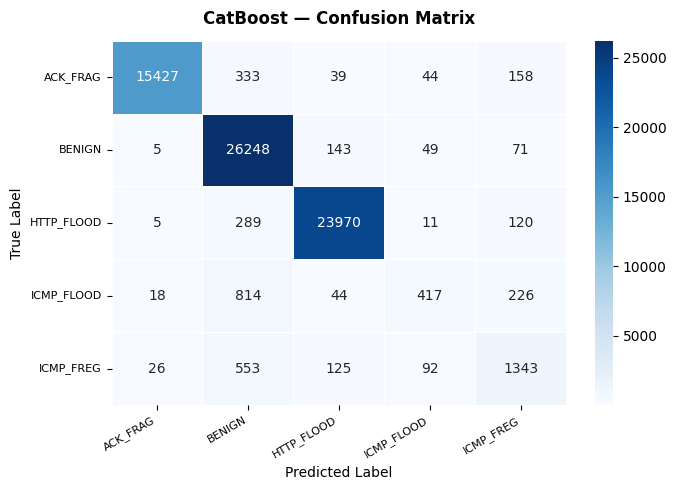

In [36]:
cat_model = CatBoostClassifier(
    iterations        = 300,
    depth             =4,
    random_seed       = 42,
    verbose           = 0              # suppress per-iteration logs
)

cat_model, cat_preds = train_and_evaluate(
    name     = "CatBoost",
    model    = cat_model,
    X_tr     = X_train,
    y_tr     = y_train,
    X_vl     = X_val,
    y_vl     = y_val,
    X_te     = X_test,
    y_te     = y_test
)

### Step 3: Model 1 - RandomForest

Random Forest builds many decision trees on random feature subsets and
aggregates their votes. It is robust to overfitting, handles high-dimensional
data well, and provides built-in feature importance scores.


  🌲 Random Forest
  ⏱  Training Time    : 13.9006s
  🖥  Training CPU     : 92.36%
  ⏱  Inference Time   : 0.1983s
  🖥  Inference CPU    : 52.10%

  📊 Metrics (Test Set):
     Accuracy  : 96.07%
     Precision : 96.39%
     Recall    : 96.07%
     F1 Score  : 96.20%

  📋 Classification Report:
              precision    recall  f1-score   support

    ACK_FRAG       1.00      0.97      0.98     16001
      BENIGN       0.97      0.97      0.97     26516
  HTTP_FLOOD       0.99      0.98      0.99     24395
  ICMP_FLOOD       0.52      0.61      0.56      1519
   ICMP_FREG       0.69      0.79      0.74      2139

    accuracy                           0.96     70570
   macro avg       0.83      0.86      0.85     70570
weighted avg       0.96      0.96      0.96     70570



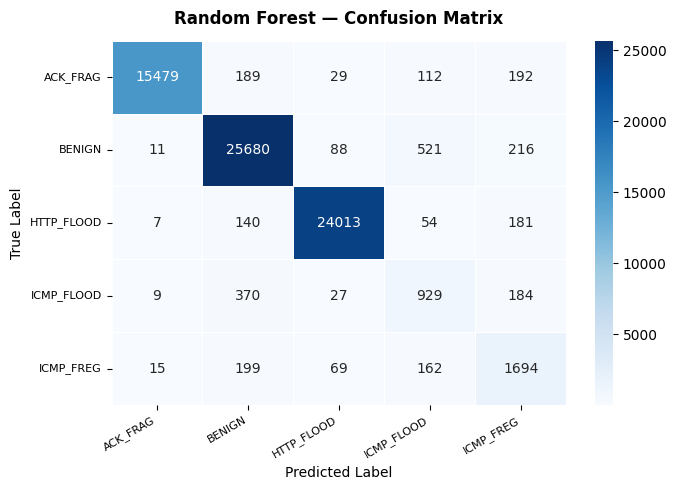

In [38]:

rf_model = RandomForestClassifier(
    n_estimators  = 50,
    criterion = 'entropy',
    max_depth     = None,
    min_samples_split = 5,
    min_samples_leaf  = 2,
    max_features  = "sqrt",
    class_weight  = "balanced",
    n_jobs        = -1,
    random_state  = 42,
    verbose       = 0
)

rf_model, rf_preds = train_and_evaluate(
    name  = "Random Forest",
    model = rf_model,
    X_tr  = X_train,
    y_tr  = y_train,
    X_vl  = X_val,
    y_vl  = y_val,
    X_te  = X_test,
    y_te  = y_test
)

### Step 4: Model 2- ExtraTrees

Extra Trees extends Random Forest by also randomising the split thresholds
at each node, making it faster to train and often more robust against
noisy features — a useful property in network traffic classification.


  🌲 Extra Trees
  ⏱  Training Time    : 11.5106s
  🖥  Training CPU     : 95.25%
  ⏱  Inference Time   : 0.2932s
  🖥  Inference CPU    : 59.75%

  📊 Metrics (Test Set):
     Accuracy  : 94.95%
     Precision : 96.30%
     Recall    : 94.95%
     F1 Score  : 95.47%

  📋 Classification Report:
              precision    recall  f1-score   support

    ACK_FRAG       1.00      0.97      0.98     16001
      BENIGN       0.97      0.93      0.95     26516
  HTTP_FLOOD       0.99      0.98      0.99     24395
  ICMP_FLOOD       0.40      0.73      0.52      1519
   ICMP_FREG       0.62      0.81      0.70      2139

    accuracy                           0.95     70570
   macro avg       0.80      0.88      0.83     70570
weighted avg       0.96      0.95      0.95     70570



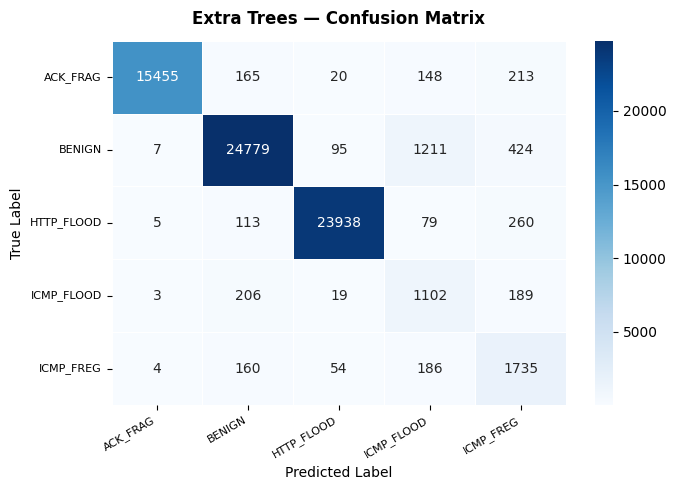

In [39]:

et_model = ExtraTreesClassifier(
    n_estimators      = 70,
    max_depth         = None,
    min_samples_split = 5,
    min_samples_leaf  = 2,
    max_features      = "sqrt",
    class_weight      = "balanced",
    n_jobs            = -1,
    random_state      = 42,
    verbose           = 0
)

et_model, et_preds = train_and_evaluate(
    name  = "Extra Trees",
    model = et_model,
    X_tr  = X_train,
    y_tr  = y_train,
    X_vl  = X_val,
    y_vl  = y_val,
    X_te  = X_test,
    y_te  = y_test
)

### Step 5: Model 3 - AdaBoost(AdaptiveBoost)

AdaBoost trains shallow decision trees sequentially, each correcting the
errors of the previous one by upweighting misclassified samples. It is
highly interpretable and effective on well-cleaned, balanced datasets.


  🌲 AdaBoost
  ⏱  Training Time    : 458.7343s
  🖥  Training CPU     : 17.35%
  ⏱  Inference Time   : 1.2080s
  🖥  Inference CPU    : 17.06%

  📊 Metrics (Test Set):
     Accuracy  : 94.08%
     Precision : 93.34%
     Recall    : 94.08%
     F1 Score  : 93.21%

  📋 Classification Report:
              precision    recall  f1-score   support

    ACK_FRAG       1.00      0.96      0.98     16001
      BENIGN       0.90      0.99      0.94     26516
  HTTP_FLOOD       0.98      0.97      0.98     24395
  ICMP_FLOOD       0.55      0.09      0.15      1519
   ICMP_FREG       0.67      0.46      0.55      2139

    accuracy                           0.94     70570
   macro avg       0.82      0.69      0.72     70570
weighted avg       0.93      0.94      0.93     70570



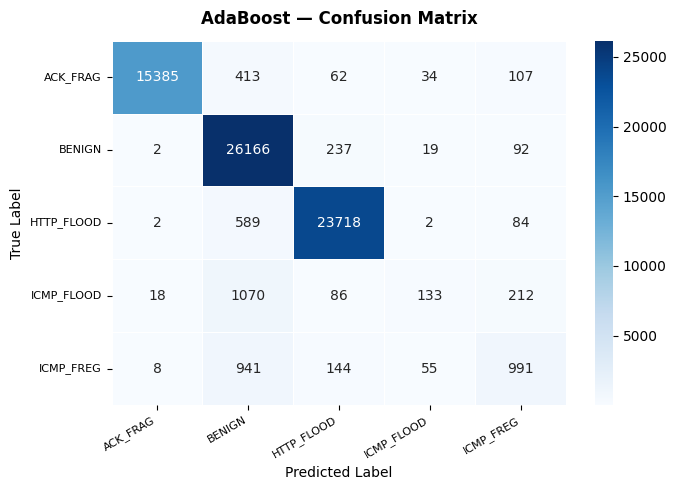

In [14]:

from sklearn.ensemble import AdaBoostClassifier
from sklearn.tree import DecisionTreeClassifier

adaboost_base = DecisionTreeClassifier(
    max_depth    = 4,
    random_state = 42
)

ada_model = AdaBoostClassifier(
    estimator        = adaboost_base,
    n_estimators     = 50,
    learning_rate    = 0.2,
    algorithm        = "SAMME",
    random_state     = 42
)

ada_model, ada_preds = train_and_evaluate(
    name  = "AdaBoost",
    model = ada_model,
    X_tr  = X_train,
    y_tr  = y_train,
    X_vl  = X_val,
    y_vl  = y_val,
    X_te  = X_test,
    y_te  = y_test
)

### Step 6: Model 4 - LightGBM(Light Gradient Boosting Machine)

LightGBM uses a leaf-wise tree growth strategy and histogram-based splitting,
making it significantly faster and more memory-efficient than XGBoost on
large datasets while maintaining competitive accuracy. Well-suited for
high-throughput SDN-IoT traffic classification tasks.


  🌲 LightGBM
  ⏱  Training Time    : 71.4475s
  🖥  Training CPU     : 63.98%
  ⏱  Inference Time   : 3.4515s
  🖥  Inference CPU    : 88.23%

  📊 Metrics (Test Set):
     Accuracy  : 95.29%
     Precision : 96.64%
     Recall    : 95.29%
     F1 Score  : 95.79%

  📋 Classification Report:
              precision    recall  f1-score   support

    ACK_FRAG       1.00      0.97      0.98     16001
      BENIGN       0.98      0.93      0.96     26516
  HTTP_FLOOD       0.99      0.98      0.99     24395
  ICMP_FLOOD       0.42      0.79      0.55      1519
   ICMP_FREG       0.64      0.82      0.72      2139

    accuracy                           0.95     70570
   macro avg       0.81      0.90      0.84     70570
weighted avg       0.97      0.95      0.96     70570



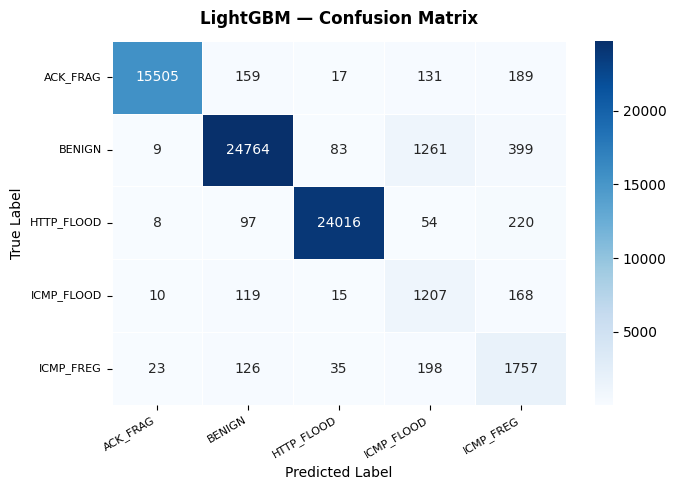

In [15]:
lgbm_model = LGBMClassifier(
    n_estimators      = 500,
    learning_rate     = 0.05,
    max_depth         = -1,
    num_leaves        = 63,
    min_child_samples = 20,
    subsample         = 0.8,
    colsample_bytree  = 0.8,
    class_weight      = "balanced",
    n_jobs            = -1,
    random_state      = 42,
    verbose           = -1
)

lgbm_model, lgbm_preds = train_and_evaluate(
    name  = "LightGBM",
    model = lgbm_model,
    X_tr  = X_train,
    y_tr  = y_train,
    X_vl  = X_val,
    y_vl  = y_val,
    X_te  = X_test,
    y_te  = y_test
)


### Step 7: Model 5 - XGBoost(eXtreme Gradient Boosting)
XGBoost uses level-wise tree growth with L1/L2 regularisation, making it
highly accurate and resistant to overfitting. It is one of the most widely
used models in network intrusion detection benchmarks, serving here as
both a strong competitor and a deployment candidate.


  🌲 XGBoost
  ⏱  Training Time    : 62.9847s
  🖥  Training CPU     : 98.12%
  ⏱  Inference Time   : 0.9786s
  🖥  Inference CPU    : 83.46%

  📊 Metrics (Test Set):
     Accuracy  : 96.35%
     Precision : 96.15%
     Recall    : 96.35%
     F1 Score  : 96.13%

  📋 Classification Report:
              precision    recall  f1-score   support

    ACK_FRAG       0.99      0.97      0.98     16001
      BENIGN       0.95      0.99      0.97     26516
  HTTP_FLOOD       0.99      0.99      0.99     24395
  ICMP_FLOOD       0.73      0.41      0.53      1519
   ICMP_FREG       0.75      0.71      0.73      2139

    accuracy                           0.96     70570
   macro avg       0.88      0.81      0.84     70570
weighted avg       0.96      0.96      0.96     70570



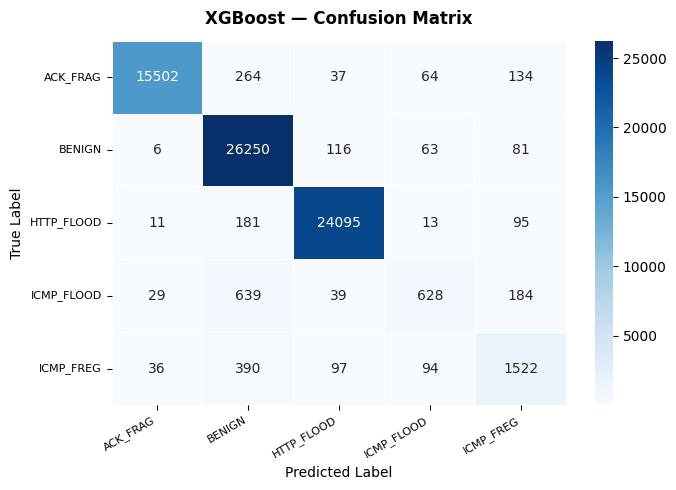

In [42]:

xgb_model = XGBClassifier(
    n_estimators      = 500,
    learning_rate     = 0.05,
    verbose           = -1
)

xgb_model, lgbm_preds = train_and_evaluate(
    name  = "XGBoost",
    model = xgb_model,
    X_tr  = X_train,
    y_tr  = y_train,
    X_vl  = X_val,
    y_vl  = y_val,
    X_te  = X_test,
    y_te  = y_test
)

### ===================================================================
#         Results Summary
### ===================================================================

Consolidates all model metrics into a single ranked DataFrame.
Models are ranked by F1 score (weighted) — the most balanced metric
for multi-class classification with real-world network traffic data.
This table feeds directly into the visualisation cells that follow.

In [17]:

results_df = pd.DataFrame(results)

# Convert to percentages for readability
results_df["accuracy"]  = results_df["accuracy"]  * 100
results_df["precision"] = results_df["precision"] * 100
results_df["recall"]    = results_df["recall"]    * 100
results_df["f1"]        = results_df["f1"]        * 100

# Rank by F1 
results_df = results_df.sort_values("f1", ascending=False).reset_index(drop=True)
results_df.index += 1                     # rank starts at 1

# Rename columns for display 
display_df = results_df.rename(columns={
    "model"          : "Model",
    "train_time"     : "Train Time (s)",
    "inference_time" : "Infer Time (s)",
    "train_cpu"      : "Train CPU (%)",
    "inference_cpu"  : "Infer CPU (%)",
    "accuracy"       : "Accuracy (%)",
    "precision"      : "Precision (%)",
    "recall"         : "Recall (%)",
    "f1"             : "F1 Score (%)",
})

print("🏆 Ensemble Model Comparison — Ranked by F1 Score")
print("=" * 75)
print(display_df.to_string(index=True))
print("=" * 75)
print(f"\n🥇 Best Model : {results_df.iloc[0]['model']}")
print(f"   F1 Score   : {results_df.iloc[0]['f1']:.2f}%")
print(f"   Accuracy   : {results_df.iloc[0]['accuracy']:.2f}%")

# Save results for visualisation 
results_df.to_csv("ensemble_results.csv", index=False)
print("\n💾 Results saved to ensemble_results.csv")

🏆 Ensemble Model Comparison — Ranked by F1 Score
           Model  Train Time (s)  Infer Time (s)  Train CPU (%)  Infer CPU (%)  Accuracy (%)  Precision (%)  Recall (%)  F1 Score (%)
1  Random Forest          9.4869          0.1595        94.3900        14.9000       96.0100        96.3700     96.0100       96.1600
2       LightGBM         71.5822          3.5605        63.9900        90.8800       95.2900        96.6400     95.2900       95.7900
3       LightGBM         71.4475          3.4515        63.9800        88.2300       95.2900        96.6400     95.2900       95.7900
4    Extra Trees         10.0931          0.2298        94.9800        51.8000       94.9500        96.3000     94.9500       95.4700
5       AdaBoost        458.7343          1.2080        17.3500        17.0600       94.0800        93.3400     94.0800       93.2100

🥇 Best Model : Random Forest
   F1 Score   : 96.16%
   Accuracy   : 96.01%

💾 Results saved to ensemble_results.csv


### Save the models

In [18]:


joblib.dump(rf_model,        f"{SAVE_PATH}/rf_model.pkl")
joblib.dump(et_model,        f"{SAVE_PATH}/et_model.pkl")
joblib.dump(ada_model,        f"{SAVE_PATH}/ada_model.pkl")
joblib.dump(lgbm_model,        f"{SAVE_PATH}/lgbm_model.pkl")
joblib.dump(xgb_model,        f"{SAVE_PATH}/xgb_model.pkl")
joblib.dump(scaler,          f"{SAVE_PATH}/scaler.pkl")
joblib.dump(le,              f"{SAVE_PATH}/label_encoder.pkl")
joblib.dump(X_raw.columns.tolist(), f"{SAVE_PATH}/selected_features.pkl")

print("✅ Random Forest model and artefacts saved — ready for deployment.")

NameError: name 'SAVE_PATH' is not defined

# Model Preparation for Deployment

RandomForest is the best classifier as seen above, so we use it for real-time deployment in an SDN-IoT environment

### Step 1: Check which features are important in RandomForest

Top 20 Features used by Random Forest:
                   feature  importance
        Packet Length Mean      0.0778
         Packet Length Max      0.0601
        FWD Init Win Bytes      0.0599
         Packet Length Std      0.0468
            Flow Packets/s      0.0407
            SYN Flag Count      0.0405
Total Length of Bwd Packet      0.0401
             Flow IAT Mean      0.0375
     Bwd Packet Length Max      0.0363
              Flow IAT Max      0.0356
     Fwd Packet Length Min      0.0353
             Flow Duration      0.0351
             Bwd Packets/s      0.0315
          Fwd Seg Size Min      0.0301
            RST Flag Count      0.0285
     Fwd Packet Length Max      0.0275
              Flow Bytes/s      0.0269
     Bwd Packet Length Min      0.0252
Total Length of Fwd Packet      0.0242
         Packet Length Min      0.0182


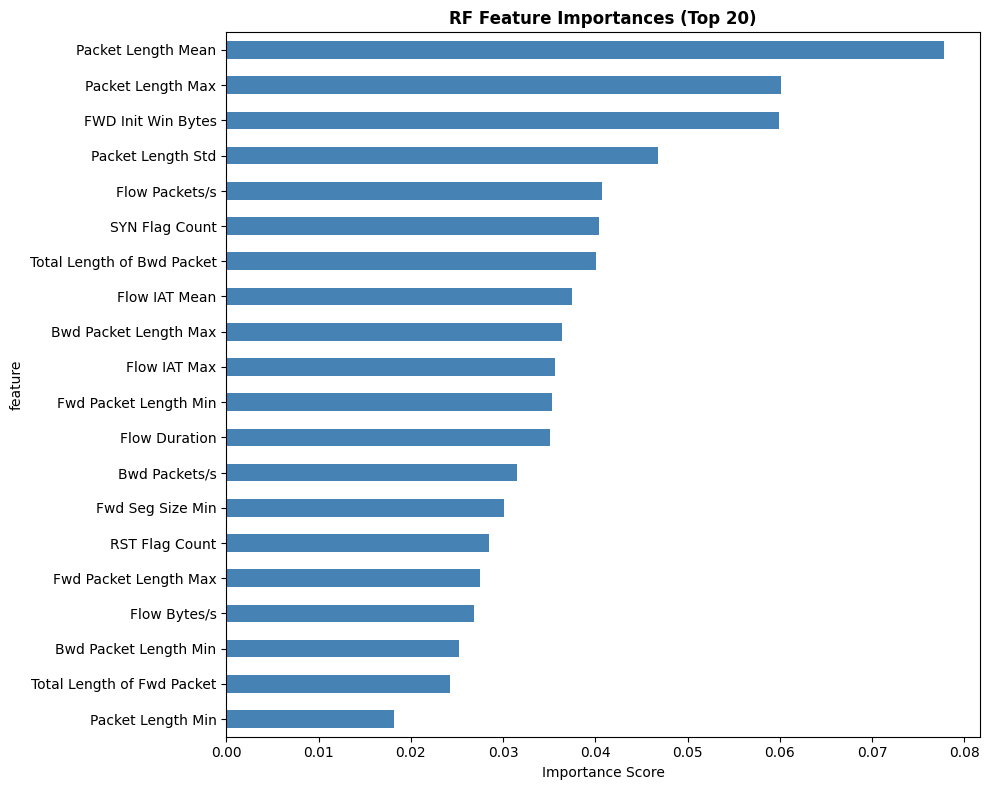


✅ Top features saved for controller use.


In [42]:

importances = rf_model.feature_importances_
feature_names = X_raw.columns.tolist()

feat_imp_df = pd.DataFrame({
    "feature"    : feature_names,
    "importance" : importances
}).sort_values("importance", ascending=False).head(20)

print("Top 20 Features used by Random Forest:")
print(feat_imp_df.to_string(index=False))

feat_imp_df.plot(
    kind="barh", x="feature", y="importance",
    figsize=(10, 8), color="steelblue", legend=False
)
plt.title("RF Feature Importances (Top 20)", fontweight="bold")
plt.xlabel("Importance Score")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig("rf_feature_importances.png", dpi=150)
plt.show()
os.makedirs(PARENT_DIRECTORY+"/preprocessed", exist_ok=True)
# Save top features list for controller use
top_features = feat_imp_df["feature"].tolist()
joblib.dump(top_features, f"{PARENT_DIRECTORY}/preprocessed/top_features.pkl")
print("\n✅ Top features saved for controller use.")

### Step 2: Its crucial to find the optimal threshold for classification


In [47]:

# Get probabilities from RF on test set
rf_proba   = rf_model.predict_proba(X_test)
rf_max_prob = rf_proba.max(axis=1)
rf_pred_class = rf_proba.argmax(axis=1)

y_test_arr = y_test.values if hasattr(y_test, "values") else y_test

# Benign class index
benign_idx = list(le.classes_).index("BENIGN")

thresholds = np.arange(0.50, 0.99, 0.05)
print(f"{'Threshold':>12} | {'Precision':>10} | {'Recall':>10} | {'FP Rate':>10} | {'Flagged%':>10}")
print("-" * 65)

for t in thresholds:
    # Only flag as attack if confidence >= threshold AND predicted non-benign
    flagged_attack = (rf_pred_class != benign_idx) & (rf_max_prob >= t)
    actual_attack  = (y_test_arr != benign_idx)

    tp = ((flagged_attack) & (actual_attack)).sum()
    fp = ((flagged_attack) & (~actual_attack)).sum()
    fn = ((~flagged_attack) & (actual_attack)).sum()
    tn = ((~flagged_attack) & (~actual_attack)).sum()

    precision = tp / (tp + fp) if (tp + fp) > 0 else 0
    recall    = tp / (tp + fn) if (tp + fn) > 0 else 0
    fp_rate   = fp / (fp + tn) if (fp + tn) > 0 else 0
    flagged_pct = flagged_attack.mean() * 100

    print(f"{t:>12.2f} | {precision:>10.4f} | {recall:>10.4f} | "
          f"{fp_rate:>10.4f} | {flagged_pct:>9.1f}%")

# Save best threshold (highest F1)
print("\n✅ Use this table to pick your deployment threshold.")
print("   Recommended: highest threshold where Recall stays above 0.95")

   Threshold |  Precision |     Recall |    FP Rate |   Flagged%
-----------------------------------------------------------------
        0.50 |     0.9842 |     0.9621 |     0.0256 |      61.0%
        0.55 |     0.9871 |     0.9536 |     0.0207 |      60.3%
        0.60 |     0.9896 |     0.9465 |     0.0165 |      59.7%
        0.65 |     0.9918 |     0.9394 |     0.0129 |      59.1%
        0.70 |     0.9931 |     0.9325 |     0.0107 |      58.6%
        0.75 |     0.9949 |     0.9243 |     0.0079 |      58.0%
        0.80 |     0.9962 |     0.9160 |     0.0058 |      57.4%
        0.85 |     0.9974 |     0.9055 |     0.0039 |      56.7%
        0.90 |     0.9983 |     0.8899 |     0.0025 |      55.6%
        0.95 |     0.9994 |     0.8688 |     0.0009 |      54.3%

✅ Use this table to pick your deployment threshold.
   Recommended: highest threshold where Recall stays above 0.95


### Step 3: Save all Model's Artefacts for deployment in SDN

In [53]:
print("💾 Saving model artefacts for SDN-IoT controller deployment...\n")

ARTEFACT_DIR = PARENT_DIRECTORY+"/preprocessed"
joblib.dump(rf_model, f"{ARTEFACT_DIR}/best_model_rf.pkl")
print(f"  ✅ RF model saved          → best_model_rf.pkl")
print(f"     Estimators              : {rf_model.n_estimators}")
print(f"     Features expected       : {rf_model.n_features_in_}")
print(f"     Classes                 : {rf_model.n_classes_}")


joblib.dump(le, f"{ARTEFACT_DIR}/label_encoder.pkl")
print(f"\n  ✅ Label encoder saved     → label_encoder.pkl")
for idx, cls in enumerate(le.classes_):
    print(f"     [{idx}] {cls}")


# joblib.dump(scaler, f"{ARTEFACT_DIR}/scaler.pkl")
# print(f"\n  ✅ Scaler saved            → scaler.pkl")
# print(f"     Type                    : {type(scaler).__name__}")
# print(f"     Feature count           : {scaler.n_features_in_}")


selected_features = X_raw.columns.tolist()
joblib.dump(selected_features, f"{ARTEFACT_DIR}/selected_features.pkl")
print(f"\n  ✅ Selected features saved → selected_features.pkl")
print(f"     Feature count           : {len(selected_features)}")


class_mapping   = {cls: int(idx) for idx, cls in enumerate(le.classes_)}
reverse_mapping = {int(idx): cls for idx, cls in enumerate(le.classes_)}

joblib.dump(class_mapping,   f"{ARTEFACT_DIR}/class_mapping.pkl")
joblib.dump(reverse_mapping, f"{ARTEFACT_DIR}/reverse_mapping.pkl")

with open(f"{ARTEFACT_DIR}/class_mapping.json", "w") as f:
    json.dump(class_mapping, f, indent=2)
with open(f"{ARTEFACT_DIR}/reverse_mapping.json", "w") as f:
    json.dump(reverse_mapping, f, indent=2)

print(f"\n  ✅ Class mappings saved    → class_mapping.pkl / .json")
print(f"                             → reverse_mapping.pkl / .json")


importances    = rf_model.feature_importances_
feat_imp_df    = pd.DataFrame({
    "feature"    : selected_features,
    "importance" : importances
}).sort_values("importance", ascending=False)

top_features   = feat_imp_df["feature"].tolist()
top_20_features = feat_imp_df.head(20)["feature"].tolist()

joblib.dump(top_features,    f"{ARTEFACT_DIR}/top_features.pkl")
joblib.dump(top_20_features, f"{ARTEFACT_DIR}/top_20_features.pkl")


feat_imp_df.to_csv(f"{ARTEFACT_DIR}/feature_importances.csv", index=False)

print(f"\n  ✅ Feature importances saved → top_features.pkl")
print(f"                               → top_20_features.pkl")
print(f"                               → feature_importances.csv")
print(f"\n  Top 10 most important features:")
for i, row in feat_imp_df.head(10).iterrows():
    print(f"     {row['feature']:<45} : {row['importance']:.6f}")

    
benign_idx = int(list(le.classes_).index("BENIGN"))
joblib.dump(benign_idx, f"{ARTEFACT_DIR}/benign_class_idx.pkl")
print(f"\n  ✅ Benign class index saved → benign_class_idx.pkl")
print(f"     BenignTraffic index     : {benign_idx}")


DEPLOYMENT_THRESHOLD = 0.85
joblib.dump(DEPLOYMENT_THRESHOLD, f"{ARTEFACT_DIR}/confidence_threshold.pkl")

with open(f"{ARTEFACT_DIR}/confidence_threshold.json", "w") as f:
    json.dump({"confidence_threshold": DEPLOYMENT_THRESHOLD}, f, indent=2)

print(f"\n  ✅ Confidence threshold saved → confidence_threshold.pkl / .json")
print(f"     Threshold               : {DEPLOYMENT_THRESHOLD}")

# ── 9. Feature zero-vector template (controller initialises new flows with this)
zero_vector = np.zeros(len(selected_features), dtype=np.float32)
joblib.dump(zero_vector, f"{ARTEFACT_DIR}/zero_feature_vector.pkl")
print(f"\n  ✅ Zero feature vector saved → zero_feature_vector.pkl")
print(f"     Shape                   : {zero_vector.shape}")

# ── 10. Artefact manifest — single file listing everything ────────────────────
manifest = {
    "model"              : "best_model_rf.pkl",
    "label_encoder"      : "label_encoder.pkl",
    "scaler"             : "scaler.pkl",
    "selected_features"  : "selected_features.pkl",
    "class_mapping"      : "class_mapping.pkl",
    "reverse_mapping"    : "reverse_mapping.pkl",
    "top_features"       : "top_features.pkl",
    "top_20_features"    : "top_20_features.pkl",
    "benign_class_idx"   : "benign_class_idx.pkl",
    "confidence_threshold": "confidence_threshold.pkl",
    "zero_feature_vector": "zero_feature_vector.pkl",
    "n_features"         : len(selected_features),
    "n_classes"          : len(le.classes_),
    "classes"            : list(le.classes_),
    "benign_label"       : "BenignTraffic",
    "benign_class_idx"   : benign_idx,
    "confidence_threshold_value" : DEPLOYMENT_THRESHOLD,
}

with open(f"{ARTEFACT_DIR}/artefact_manifest.json", "w") as f:
    json.dump(manifest, f, indent=2)

print(f"\n  ✅ Manifest saved           → artefact_manifest.json")

# ── Final summary ─────────────────────────────────────────────────────────────
saved_files = os.listdir(ARTEFACT_DIR)
total_size  = sum(
    os.path.getsize(os.path.join(ARTEFACT_DIR, f))
    for f in saved_files
) / 1e6

print(f"\n{'='*60}")
print(f"  ✅ All artefacts saved successfully!")
print(f"  📁 Directory    : {ARTEFACT_DIR}")
print(f"  📦 Files saved  : {len(saved_files)}")
print(f"  💽 Total size   : {total_size:.2f} MB")
print(f"{'='*60}")
print(f"\n  Next step: copy artefacts to ~/pox/ext/artefacts/")
print(f"  cp -r {ARTEFACT_DIR}/* ~/pox/ext/artefacts/")


💾 Saving model artefacts for SDN-IoT controller deployment...

  ✅ RF model saved          → best_model_rf.pkl
     Estimators              : 50
     Features expected       : 47
     Classes                 : 5

  ✅ Label encoder saved     → label_encoder.pkl
     [0] ACK_FRAG
     [1] BENIGN
     [2] HTTP_FLOOD
     [3] ICMP_FLOOD
     [4] ICMP_FREG

  ✅ Selected features saved → selected_features.pkl
     Feature count           : 47

  ✅ Class mappings saved    → class_mapping.pkl / .json
                             → reverse_mapping.pkl / .json

  ✅ Feature importances saved → top_features.pkl
                               → top_20_features.pkl
                               → feature_importances.csv

  Top 10 most important features:
     Packet Length Mean                            : 0.077813
     Packet Length Max                             : 0.060147
     FWD Init Win Bytes                            : 0.059871
     Packet Length Std                             : 0.046788
